In [1]:
import torch 
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from neural_net import RobotNet 
import matplotlib.pyplot as plt

model loaded


In [2]:
df=pd.read_csv('dataset.csv')

In [3]:
df.head()

,left_sensor,front_sensor,right_sensor,left_motor,right_motor
0,200.0,200.0,200.0,0.457524,0.482287
1,200.0,200.0,200.0,0.457524,0.482287
2,200.0,200.0,200.0,0.457524,0.482287
3,200.0,200.0,200.0,0.457524,0.482287
4,200.0,200.0,200.0,0.457524,0.482287


In [4]:
filtered_df = df[
    (df["left_sensor"] < 175) &
    (df["front_sensor"] < 175) &
    (df["right_sensor"] < 175)
]

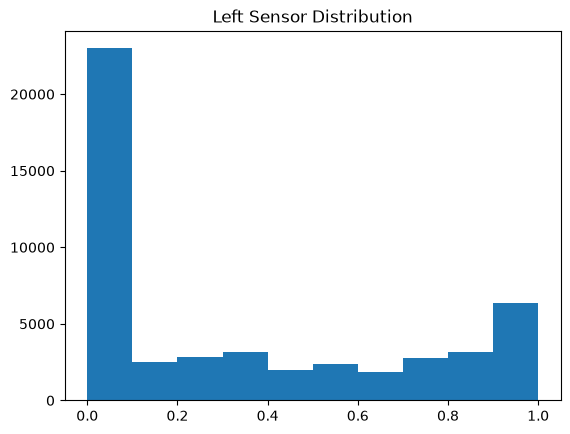

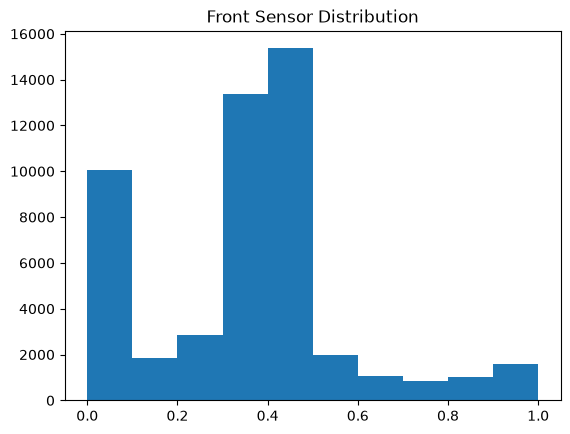

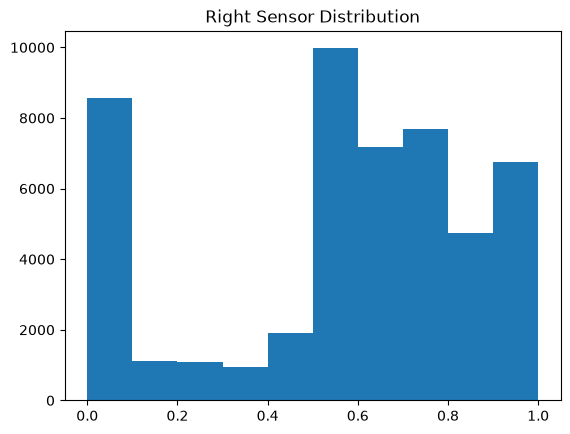

In [5]:
plt.hist(filtered_df["left_sensor"])
plt.title("Left Sensor Distribution")
plt.show()

plt.hist(filtered_df["front_sensor"])
plt.title("Front Sensor Distribution")
plt.show()

plt.hist(filtered_df["right_sensor"])
plt.title("Right Sensor Distribution")
plt.show()

In [6]:
filtered_df.describe()

,left_sensor,front_sensor,right_sensor,left_motor,right_motor
count,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000
mean,0.335552,0.349261,0.561578,0.523586,0.602417
std,0.368312,0.224639,0.306910,0.264083,0.229963
min,0.000000,0.000000,0.000000,0.200000,0.200000
25%,0.003999,0.227880,0.474092,0.200000,0.400000
50%,0.181777,0.389847,0.615453,0.400000,0.800000
75%,0.693159,0.431815,0.786863,0.800000,0.800000
max,1.000000,1.000000,1.000000,0.800000,0.800000


In [7]:
print(filtered_df["left_motor"].value_counts())
print(filtered_df["right_motor"].value_counts())

left_motor
0.8    20735
0.2    15666
0.4    10194
0.7     3388
Name: count, dtype: int64
right_motor
0.8    25860
0.4    14520
0.2     6215
0.7     3388
Name: count, dtype: int64


In [8]:
print(filtered_df["left_motor"].value_counts(normalize=True)*100)
print(filtered_df["right_motor"].value_counts(normalize=True)*100)

left_motor
0.8    41.484105
0.2    31.342657
0.4    20.394934
0.7     6.778305
Name: proportion, dtype: float64
right_motor
0.8    51.737591
0.4    29.049877
0.2    12.434228
0.7     6.778305
Name: proportion, dtype: float64


In [9]:
X=filtered_df[['left_sensor','front_sensor','right_sensor']].values
y=filtered_df[['left_motor','right_motor']].values

In [10]:
X=torch.tensor(X,dtype=torch.float32)
y=torch.tensor(y,dtype=torch.float32)

In [11]:
X

tensor([[0.5800, 0.5975, 0.5107],
        [0.5736, 0.6080, 0.4999],
        [0.5980, 0.5888, 0.4879],
        ...,
        [0.0000, 0.3837, 0.8341],
        [0.0000, 0.4500, 0.8131],
        [0.0044, 0.3955, 0.8341]])

In [12]:
y

tensor([[0.8000, 0.2000],
        [0.8000, 0.2000],
        [0.8000, 0.2000],
        ...,
        [0.8000, 0.4000],
        [0.2000, 0.8000],
        [0.8000, 0.4000]])

In [13]:
X.shape

torch.Size([49983, 3])

In [14]:
y.shape

torch.Size([49983, 2])

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
X_train.shape

torch.Size([39986, 3])

In [17]:
y_test.shape

torch.Size([9997, 2])

In [18]:
neuron=RobotNet()

In [19]:
criterion=nn.MSELoss()

In [20]:
from torch.optim import Adam

In [21]:
optimizer=torch.optim.Adam(neuron.parameters(),lr=0.001)

In [22]:
losses=[]
for epoch in range(100):
    pred=neuron(X_train)
    loss=criterion(pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch%10==0:
        print(epoch,loss.item())

0 0.07111936062574387
10 0.06862486153841019
20 0.06674204766750336
30 0.06499280780553818
40 0.06317314505577087
50 0.06123655289411545
60 0.05951278656721115
70 0.05801376327872276
80 0.05604369193315506
90 0.05350930616259575


In [23]:
torch.save(
    neuron.state_dict(),
    "model.pth"
)

print("Model saved.")

Model saved.


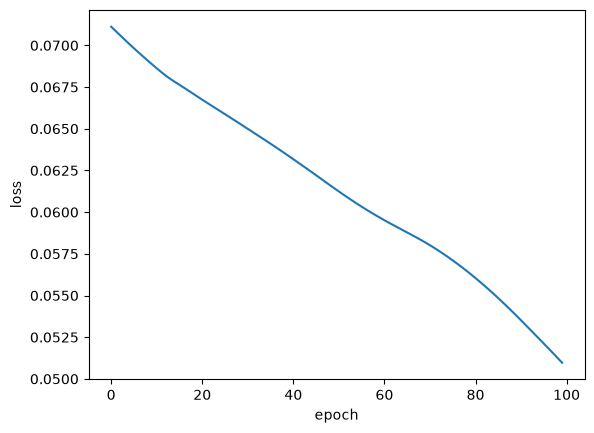

In [24]:
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [28]:
val_loss=[]
neuron.eval()
with torch.no_grad():
     for epoch in range(100):
          pred=neuron(X_test)
          loss=criterion(pred,y_test)
          val_loss.append(loss)

In [26]:
val_loss

[tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.0507, grad_fn=<MseLossBackward0>),
 tensor(0.

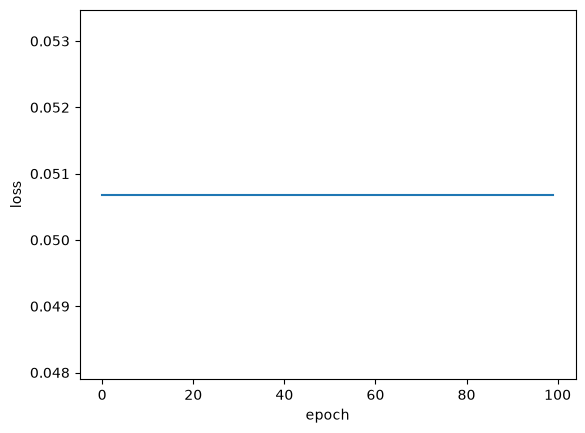

In [29]:
plt.plot(val_loss)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()